# 02 — Análise Exploratória de Dados

Fontes: `data/raw/cepea_*.parquet` e `data/raw/bcb_macro.parquet`

Foco: sazonalidade ligada ao calendário de safra, correlação com câmbio e detecção de outliers.  
Hipóteses levantadas aqui alimentam o feature engineering do notebook 03.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

RAW_DIR = Path('../data/raw')
FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

---
## 1. Carregamento

In [2]:
df_soja  = pd.read_parquet(RAW_DIR / 'cepea_soja.parquet')
df_milho = pd.read_parquet(RAW_DIR / 'cepea_milho.parquet')
df_macro = pd.read_parquet(RAW_DIR / 'bcb_macro.parquet')

df = pd.concat([df_soja, df_milho], ignore_index=True)
df['data']       = pd.to_datetime(df['data'])
df_macro['data'] = pd.to_datetime(df_macro['data'])

# Normaliza datas para fim de mês para facilitar joins
df['data'] = df['data'] + pd.offsets.MonthEnd(0)

# Câmbio diário → mensal (último valor do mês)
df_cambio = (
    df_macro.set_index('data')[['usd_brl']]
    .resample('ME').last()
    .reset_index()
)
df_cambio['data'] = df_cambio['data'] + pd.offsets.MonthEnd(0)

soja  = df[df['commodity'] == 'soja'].set_index('data').sort_index()
milho = df[df['commodity'] == 'milho'].set_index('data').sort_index()

print('soja: ', soja.shape, '| milho:', milho.shape)
print('período:', df['data'].min().date(), '→', df['data'].max().date())

soja:  (126, 3) | milho: (126, 3)
período: 2016-01-31 → 2026-06-30


---
## 2. Evolução histórica

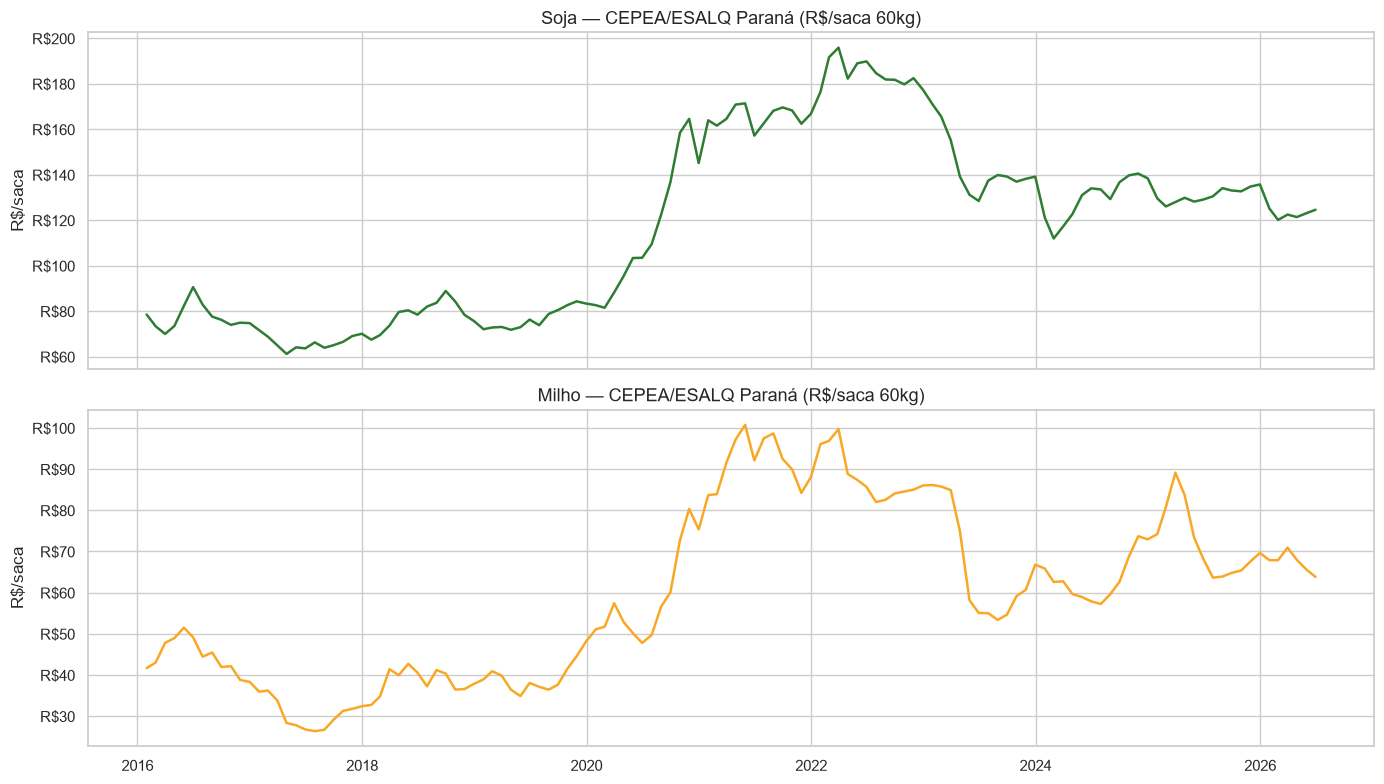

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, serie, titulo, cor in [
    (axes[0], soja,  'Soja',  '#2e7d32'),
    (axes[1], milho, 'Milho', '#f9a825'),
]:
    ax.plot(serie.index, serie['preco_rs'], color=cor, linewidth=1.8)
    ax.set_title(f'{titulo} — CEPEA/ESALQ Paraná (R$/saca 60kg)')
    ax.set_ylabel('R$/saca')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'evolucao_precos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Estatísticas descritivas

In [4]:
desc = df.groupby('commodity')['preco_rs'].describe().round(2)
display(desc)

# Coeficiente de variação — volatilidade relativa entre as duas commodities
cv = df.groupby('commodity')['preco_rs'].apply(lambda x: x.std() / x.mean() * 100).round(1)
print('\nCoeficiente de variação (%):')
print(cv.to_string())

,count,mean,std,min,25%,50%,75%,max
commodity,,,,,,,,
milho,126.0,59.71,20.78,26.33,40.96,58.54,75.21,100.72
soja,126.0,117.15,39.67,61.16,78.36,122.84,139.81,195.85



Coeficiente de variação (%):
commodity
milho    34.8
soja     33.9


---
## 4. Sazonalidade

Calendário agrícola BR:
- **Soja:** plantio out–dez / colheita mar–mai
- **Milho 1ª safra:** plantio set–out / colheita fev–mar
- **Milho 2ª safra:** plantio jan–fev / colheita jun–ago

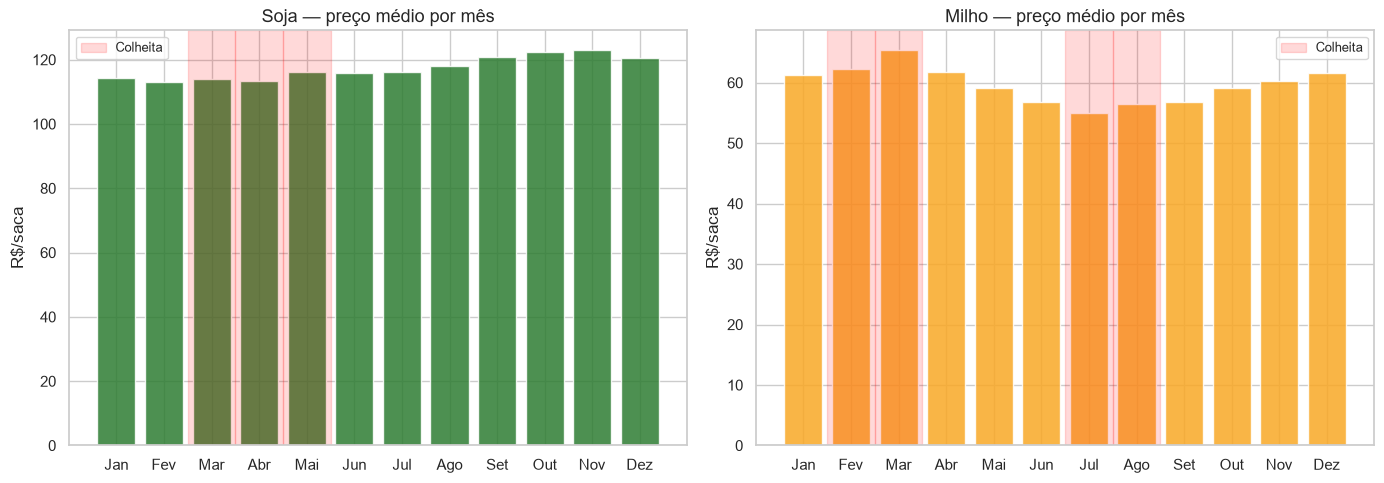

In [5]:
# Preço médio por mês do ano — revela o perfil sazonal histórico
MESES = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
COLHEITA = {'soja': [3, 4, 5], 'milho': [2, 3, 7, 8]}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (commodity, cor) in zip(axes, [('soja', '#2e7d32'), ('milho', '#f9a825')]):
    serie = df[df['commodity'] == commodity].copy()
    serie['mes'] = serie['data'].dt.month
    media = serie.groupby('mes')['preco_rs'].mean()

    ax.bar(media.index, media.values, color=cor, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MESES)
    ax.set_title(f'{commodity.capitalize()} — preço médio por mês')
    ax.set_ylabel('R$/saca')

    for mes in COLHEITA[commodity]:
        ax.axvspan(mes - 0.5, mes + 0.5, alpha=0.15, color='red',
                   label='Colheita' if mes == COLHEITA[commodity][0] else '')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'sazonalidade_mensal.png', dpi=150, bbox_inches='tight')
plt.show()

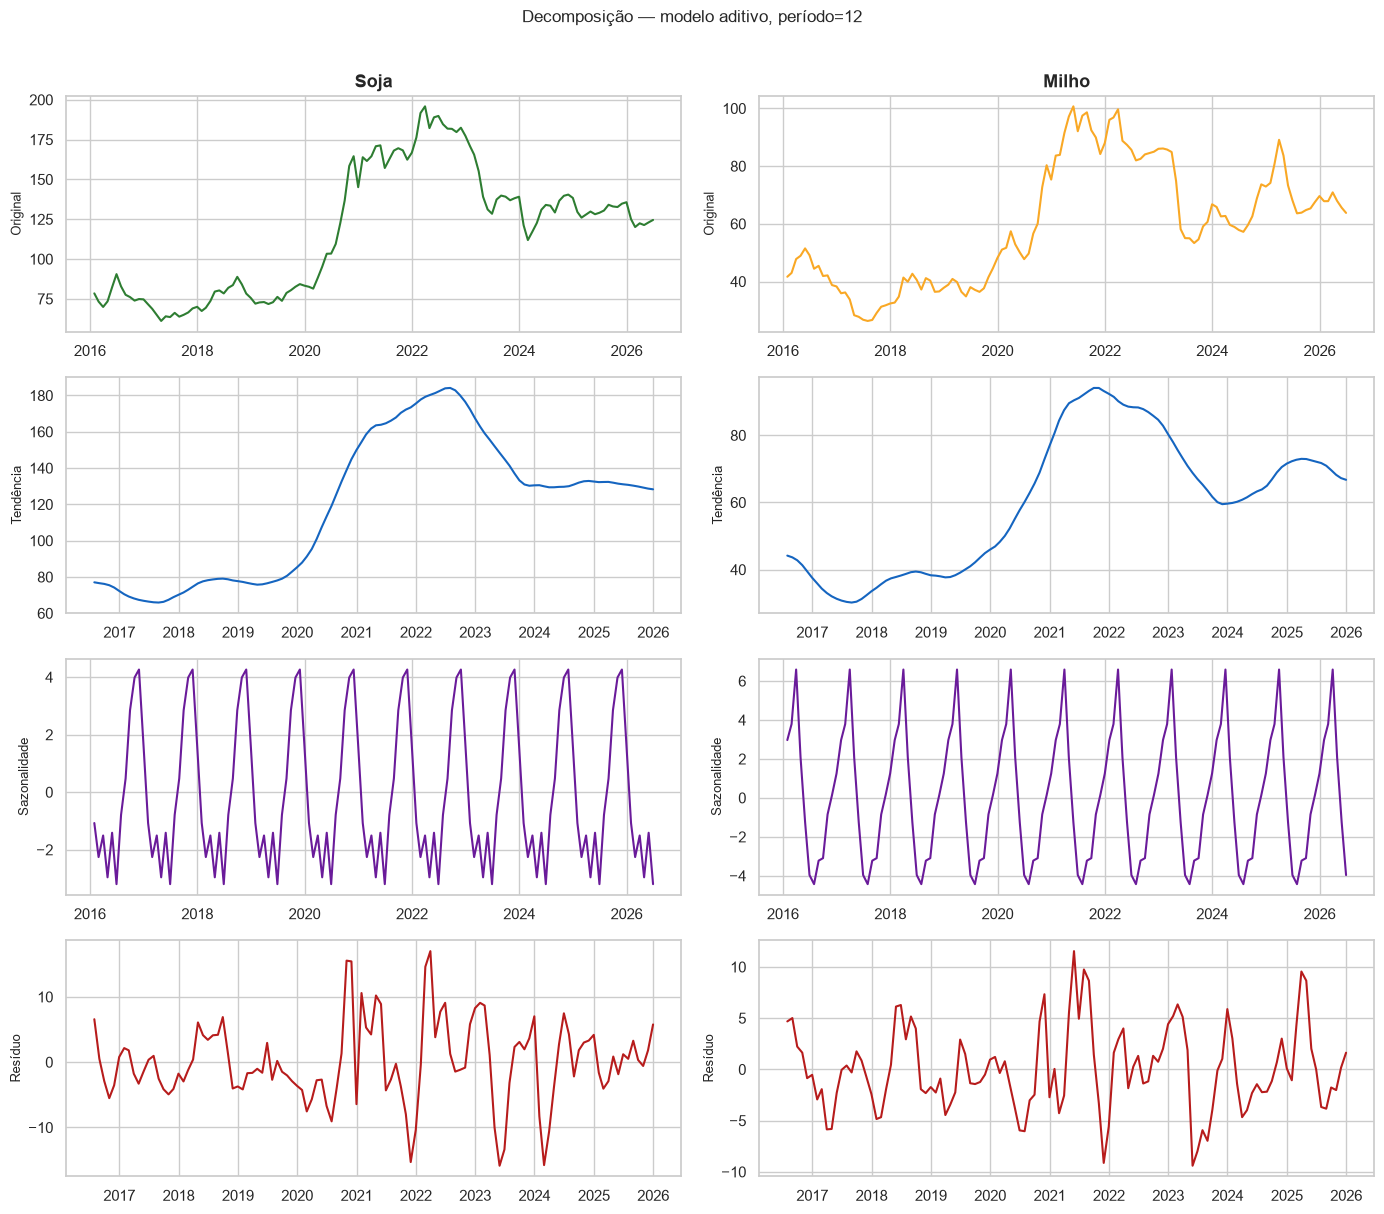

In [6]:
# Decomposição clássica: tendência + sazonalidade + resíduo
fig, axes = plt.subplots(4, 2, figsize=(14, 12))

for col, (commodity, cor) in enumerate([('soja', '#2e7d32'), ('milho', '#f9a825')]):
    serie = (
        df[df['commodity'] == commodity]
        .set_index('data')['preco_rs']
        .resample('ME').mean()
        .interpolate('linear')  # preenche eventuais gaps para não quebrar a decomposição
    )
    decomp = seasonal_decompose(serie, model='additive', period=12)

    for row, (dados, label, c) in enumerate([
        (serie,           'Original',    cor),
        (decomp.trend,    'Tendência',   '#1565c0'),
        (decomp.seasonal, 'Sazonalidade','#6a1b9a'),
        (decomp.resid,    'Resíduo',     '#b71c1c'),
    ]):
        axes[row][col].plot(dados.index, dados.values, color=c, linewidth=1.5)
        if row == 0:
            axes[row][col].set_title(commodity.capitalize(), fontweight='bold')
        axes[row][col].set_ylabel(label, fontsize=9)
        axes[row][col].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Decomposição — modelo aditivo, período=12', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'decomposicao_serie.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Correlação preço × câmbio

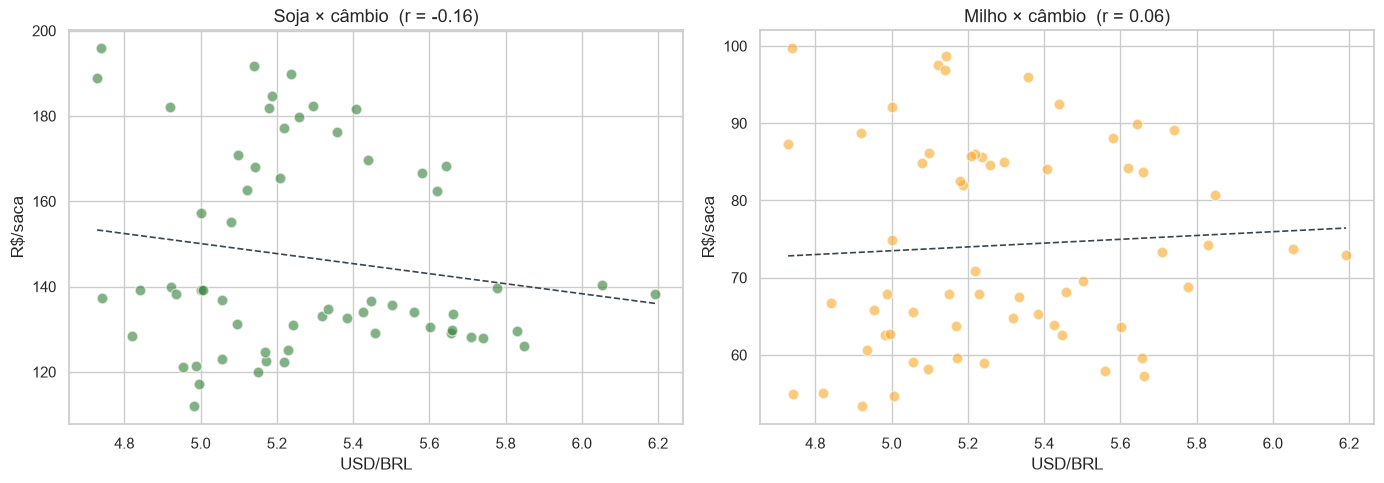

In [7]:
df_corr = df.merge(df_cambio, on='data', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (commodity, cor) in zip(axes, [('soja', '#2e7d32'), ('milho', '#f9a825')]):
    sub = df_corr[df_corr['commodity'] == commodity].dropna(subset=['preco_rs', 'usd_brl'])
    r = sub['preco_rs'].corr(sub['usd_brl'])

    ax.scatter(sub['usd_brl'], sub['preco_rs'], alpha=0.6, color=cor, edgecolors='white', s=60)
    z = np.polyfit(sub['usd_brl'], sub['preco_rs'], 1)
    x_line = sorted(sub['usd_brl'])
    ax.plot(x_line, np.poly1d(z)(x_line), '--', color='#37474f', linewidth=1.2)
    ax.set_xlabel('USD/BRL')
    ax.set_ylabel('R$/saca')
    ax.set_title(f'{commodity.capitalize()} × câmbio  (r = {r:.2f})')

plt.tight_layout()
plt.savefig(FIG_DIR / 'correlacao_cambio.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Outliers (método IQR)

soja: 0 outlier(s)
milho: 0 outlier(s)


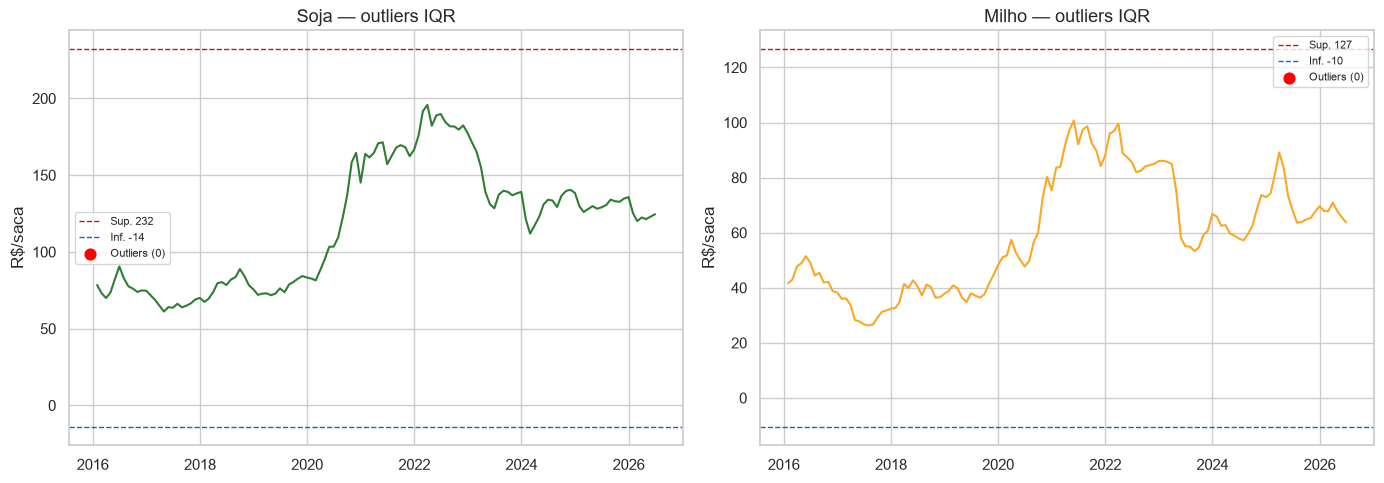

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (commodity, cor) in zip(axes, [('soja', '#2e7d32'), ('milho', '#f9a825')]):
    serie = df[df['commodity'] == commodity].set_index('data').sort_index()
    Q1, Q3 = serie['preco_rs'].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = serie[(serie['preco_rs'] < lower) | (serie['preco_rs'] > upper)]

    ax.plot(serie.index, serie['preco_rs'], color=cor, linewidth=1.5)
    ax.axhline(upper, color='#b71c1c', linestyle='--', linewidth=1, label=f'Sup. {upper:.0f}')
    ax.axhline(lower, color='#1565c0', linestyle='--', linewidth=1, label=f'Inf. {lower:.0f}')
    ax.scatter(outliers.index, outliers['preco_rs'], color='red', zorder=5, s=60, label=f'Outliers ({len(outliers)})')
    ax.set_title(f'{commodity.capitalize()} — outliers IQR')
    ax.set_ylabel('R$/saca')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    print(f'{commodity}: {len(outliers)} outlier(s)')
    if not outliers.empty:
        print(outliers[['preco_rs']].to_string(), '\n')

plt.tight_layout()
plt.savefig(FIG_DIR / 'outliers.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Variação mensal

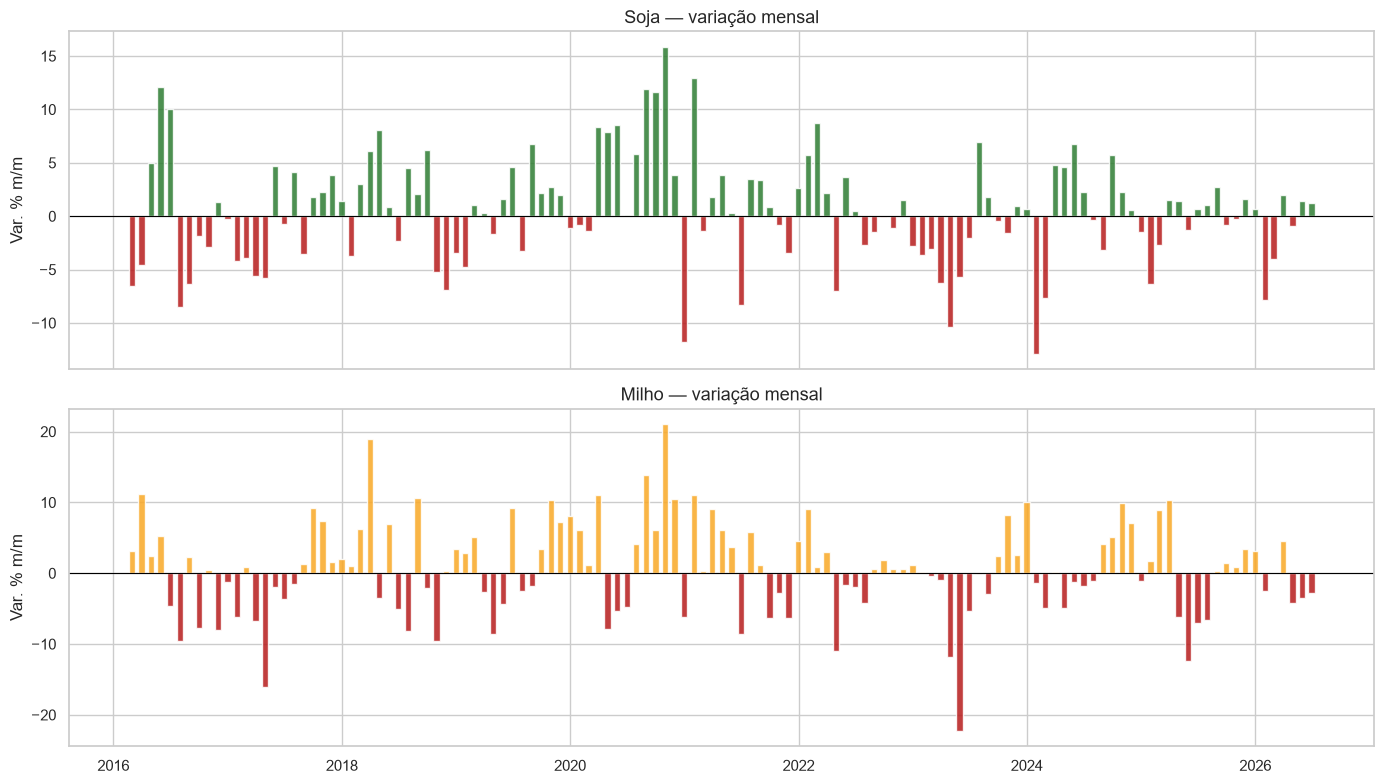

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (commodity, cor) in zip(axes, [('soja', '#2e7d32'), ('milho', '#f9a825')]):
    serie = df[df['commodity'] == commodity].set_index('data').sort_index().copy()
    serie['var_mm'] = serie['preco_rs'].pct_change() * 100
    cores = ['#b71c1c' if v < 0 else cor for v in serie['var_mm']]

    ax.bar(serie.index, serie['var_mm'], color=cores, width=20, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Var. % m/m')
    ax.set_title(f'{commodity.capitalize()} — variação mensal')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'variacao_mensal.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Hipóteses para o notebook 03

- **Lags:** testar t-1, t-2, t-3 como features preditivas
- **Câmbio defasado:** correlação pode ser mais forte com lag de 1–3 meses
- **Deflação:** série nominal pode esconder comportamento real — deflacionar pelo IPCA
- **Outliers 2021–2022:** picos de choque pós-COVID + guerra na Ucrânia — avaliar Winsorização antes do treino
- **Features sazonais:** mês, trimestre e flag de período de colheita

In [10]:
print('Figuras salvas em reports/figures/:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name}')

print('\n✅ EDA concluído.')

Figuras salvas em reports/figures/:
  correlacao_cambio.png
  decomposicao_serie.png
  evolucao_precos.png
  outliers.png
  sazonalidade_mensal.png
  variacao_mensal.png

✅ EDA concluído.
